# 🔬 Avaliação de Impacto Causal — DEAMs 24h no Brasil
### Callaway & Sant'Anna (2021) · Diferenças-em-Diferenças com adoção escalonada

Este notebook reproduz a etapa de **inferência causal** do projeto, agora em escopo
**nacional** (municípios brasileiros, 2009–2019). Avalia o impacto da conversão de
Delegacias Especializadas de Atendimento à Mulher (DEAMs) do horário comercial para
o regime de **plantão 24 horas**.

---

## 1. Hipótese e o paradoxo da cifra oculta

Avaliar a política apenas pelo volume de denúncias é falho: uma delegacia mais
acessível tende a **aumentar** os registros (reduzindo a *cifra oculta* da
subnotificação), enquanto o objetivo final é **reduzir a letalidade** (feminicídios).

**Cadeia causal:**
> Conversão para 24h → ↑ acesso institucional (mais notificações fora do horário
> comercial) → proteção ativa / medidas protetivas → ↓ letalidade (feminicídios)

Dois desfechos, em **taxa por 100 mil habitantes** (para neutralizar o porte
populacional, pois as cidades tratadas são metrópoles muito maiores):
1. **`taxa_notificacoes`** (SINAN) — canal de acesso
2. **`taxa_feminicidios`** (SIM) — canal de letalidade

**Estimador:** Callaway & Sant'Anna (CS DiD), que corrige o viés de Goodman-Bacon
presente no TWFE quando a adoção é escalonada no tempo. Contrafactual: DEAMs de
horário comercial (nunca convertidas), i.e. grupo `never_treated`.

$$ ATT(g,t) = \mathbb{E}[Y_{it}-Y_{i,g-1}\mid G=g] - \mathbb{E}[Y_{it}-Y_{i,g-1}\mid \text{nunca tratado}] $$

## 2. Configuração e carga do painel

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from diff_diff import (
    CallawaySantAnna, ImputationDiD,
    plot_event_study, plot_group_time_heatmap, plot_group_effects,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Raiz do projeto (notebook roda de codes/inferencia_causal/)
ROOT = Path.cwd()
while not (ROOT / "dados").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

painel = pd.read_csv(ROOT / "dados/consolidado/painel_deam_anual.csv")
painel = painel.rename(columns={"coorte": "first_treat"})
painel["Grupo"] = np.where(painel["first_treat"] > 0, "Tratado (24h)", "Controle (comercial)")

print("Painel:", painel.shape)
print("Municípios:", painel["id_municipio"].nunique(),
      "| Tratados:", painel.loc[painel.first_treat>0,'id_municipio'].nunique(),
      "| Controles:", painel.loc[painel.first_treat==0,'id_municipio'].nunique())
painel.head()

Painel: (3135, 25)
Municípios: 285 | Tratados: 38 | Controles: 247


,id_municipio,municipio,uf,regiao,grupo,ano_implementacao,first_treat,ano,populacao,tratado,...,viol_sexual,viol_psicologica,viol_parceiro,taxa_feminicidios,taxa_notificacoes,taxa_viol_fisica,taxa_viol_sexual,taxa_viol_psicologica,taxa_viol_parceiro,Grupo
0,1100023,Ariquemes,TO,Norte,24h,2017.0,2017,2009,85541,1,...,1,0,0,12.8593,11.6903,9.3522,1.1690,0.0000,0.0000,Tratado (24h)
1,1100023,Ariquemes,TO,Norte,24h,2017.0,2017,2010,88556,1,...,3,2,4,0.0000,44.0399,40.6522,3.3877,2.2585,4.5169,Tratado (24h)
2,1100023,Ariquemes,TO,Norte,24h,2017.0,2017,2011,91570,1,...,1,2,23,1.0921,60.0633,57.8792,1.0921,2.1841,25.1174,Tratado (24h)
3,1100023,Ariquemes,TO,Norte,24h,2017.0,2017,2012,92747,1,...,4,0,22,1.0782,36.6589,33.4243,4.3128,0.0000,23.7204,Tratado (24h)
4,1100023,Ariquemes,TO,Norte,24h,2017.0,2017,2013,101269,1,...,3,4,9,1.9749,18.7619,15.7995,2.9624,3.9499,8.8872,Tratado (24h)


## 3. Estatísticas descritivas — e por que normalizar por população

Em **contagem absoluta**, os tratados parecem ter muito mais violência. Mas isso é
porque são cidades grandes. Em **taxa /100k**, os grupos ficam comparáveis — condição
necessária para a hipótese de tendências paralelas.

In [2]:
metr_cont = ["feminicidios", "notificacoes"]
metr_taxa = ["taxa_feminicidios", "taxa_notificacoes"]

desc = painel.groupby("Grupo").agg(
    n_municipios=("id_municipio", "nunique"),
    **{m: (m, "mean") for m in metr_cont + metr_taxa + ["populacao"]}
).round(2)
display(desc.T)

# Razão tratado/controle: contagem vs taxa
tr, ct = painel[painel.first_treat>0], painel[painel.first_treat==0]
for m_c, m_t in zip(metr_cont, metr_taxa):
    r_cont = tr[m_c].mean()/ct[m_c].mean()
    r_taxa = tr[m_t].mean()/ct[m_t].mean()
    print(f"{m_c:14s} razão T/C  ->  contagem {r_cont:.2f}×  |  taxa {r_taxa:.2f}×")

Grupo,Controle (comercial),Tratado (24h)
n_municipios,247.00,38.00
feminicidios,5.85,20.03
notificacoes,182.31,448.62
taxa_feminicidios,2.65,2.95
taxa_notificacoes,79.28,59.74
populacao,236689.13,608975.04


feminicidios   razão T/C  ->  contagem 3.43×  |  taxa 1.11×
notificacoes   razão T/C  ->  contagem 2.46×  |  taxa 0.75×


## 4. Desenho de adoção escalonada (staggered)

Cada município converte para 24h em um ano diferente (a *coorte*). É exatamente esse
escalonamento que motiva o estimador CS em vez do DiD tradicional.

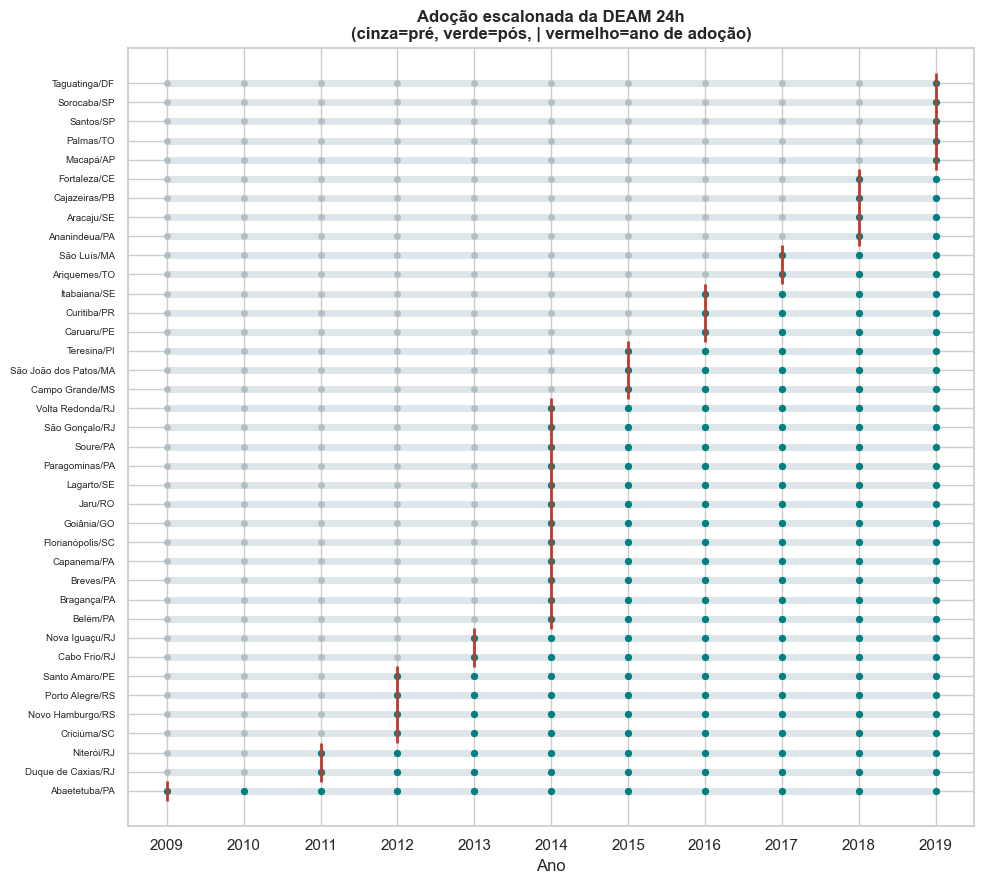

Coortes: {2009: 1, 2011: 2, 2012: 4, 2013: 2, 2014: 12, 2015: 3, 2016: 3, 2017: 2, 2018: 4, 2019: 5}


In [3]:
trat = (painel[painel.first_treat>0].drop_duplicates("id_municipio")
        .sort_values(["first_treat","municipio"]))
labels = (trat["municipio"]+"/"+trat["uf"]).tolist()

fig, ax = plt.subplots(figsize=(10, 9))
for y, (_, row) in enumerate(trat.iterrows()):
    mid, g = row["id_municipio"], row["first_treat"]
    sub = painel[painel.id_municipio==mid]
    ax.plot(sub["ano"], [y]*len(sub), "-", color="#dfe6e9", lw=5, zorder=1)
    ax.scatter(sub[sub.ano<g]["ano"], [y]*len(sub[sub.ano<g]), c="#b2bec3", s=15, zorder=2)
    ax.scatter(sub[sub.ano>=g]["ano"], [y]*len(sub[sub.ano>=g]), c="#008080", s=18, zorder=3)
    ax.scatter([g], [y], marker="|", c="#C0392B", s=220, lw=2, zorder=4)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xticks(range(2009,2020)); ax.set_xlabel("Ano")
ax.set_title("Adoção escalonada da DEAM 24h\n(cinza=pré, verde=pós, | vermelho=ano de adoção)",
             fontweight="bold")
plt.tight_layout(); plt.show()

print("Coortes:", painel[painel.first_treat>0].drop_duplicates("id_municipio")
      .groupby("first_treat").size().to_dict())

## 5. Tendências brutas (médias por grupo, em taxa /100k)

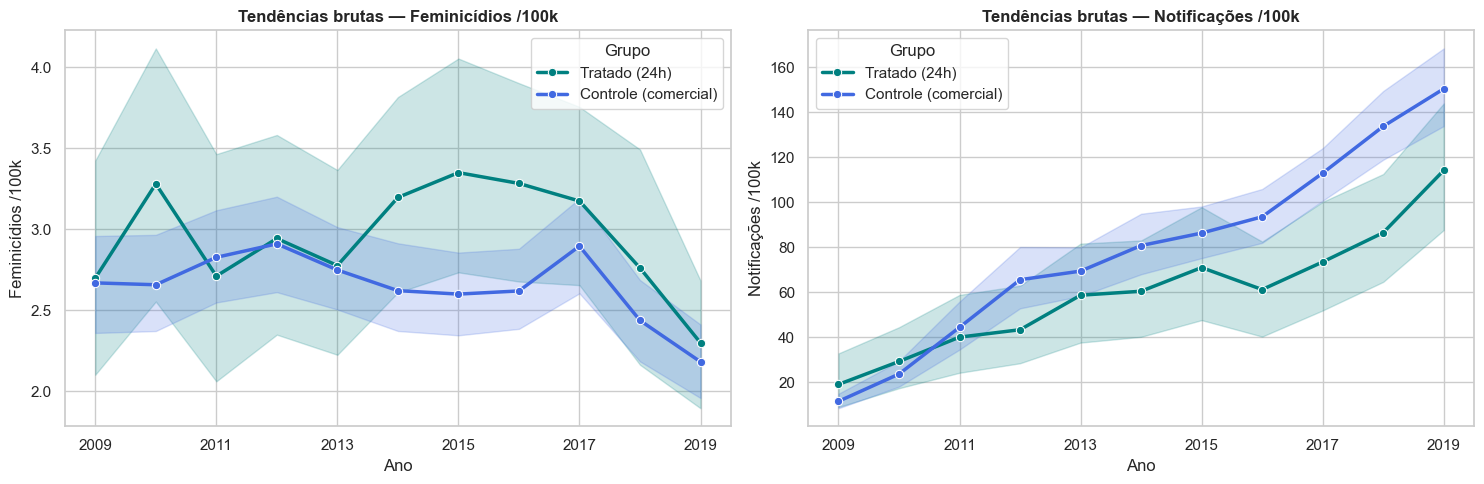

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, lab in zip(axes, metr_taxa, ["Feminicídios /100k", "Notificações /100k"]):
    sns.lineplot(data=painel, x="ano", y=col, hue="Grupo", estimator="mean",
                 errorbar=("ci",95), marker="o", lw=2.5,
                 palette={"Tratado (24h)":"#008080","Controle (comercial)":"#4169E1"}, ax=ax)
    ax.set_title(f"Tendências brutas — {lab}", fontweight="bold")
    ax.set_xticks(range(2009,2020,2)); ax.set_xlabel("Ano"); ax.set_ylabel(lab)
plt.tight_layout(); plt.show()

## 6. Estimação Callaway & Sant'Anna

`estimation_method='reg'` (sem covariáveis → tendências paralelas **incondicionais**).
`control_group='never_treated'`, erros por bootstrap (999) com cluster no município.

In [5]:
TREAT = dict(unit="id_municipio", time="ano", first_treat="first_treat")

def rodar_cs(col, aggregate):
    cs = CallawaySantAnna(control_group="never_treated", estimation_method="reg",
                          n_bootstrap=999, cluster="id_municipio", seed=42)
    return cs.fit(painel, outcome=col, aggregate=aggregate, **TREAT)

resultados = {}
for col, lab in zip(metr_taxa, ["Feminicídios /100k", "Notificações /100k"]):
    r = rodar_cs(col, "simple")
    resultados[col] = r
    ci = r.overall_conf_int
    print(f"{lab:22s} ATT = {r.overall_att:+.3f}  (SE {r.overall_se:.3f}; "
          f"IC95% [{ci[0]:.3f}, {ci[1]:.3f}]; p={r.overall_p_value:.4f})")

Feminicídios /100k     ATT = +0.438  (SE 0.255; IC95% [-0.054, 0.913]; p=0.0821)


Notificações /100k     ATT = -20.513  (SE 7.418; IC95% [-35.312, -6.578]; p=0.0010)


## 7. Event study (ATT dinâmico)

O coração do CS DiD. Coeficientes **pré-tratamento** ≈ 0 sustentam tendências
paralelas; os **pós** mostram a dinâmica do efeito.

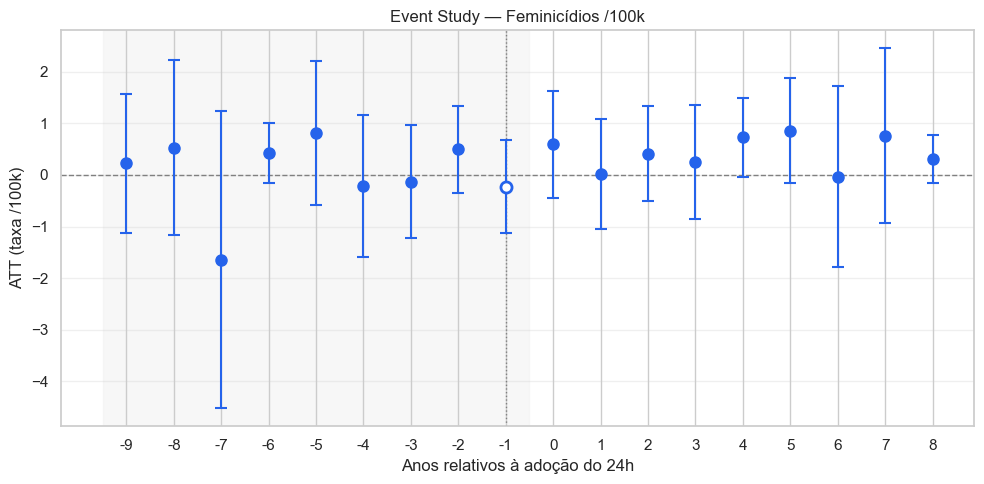

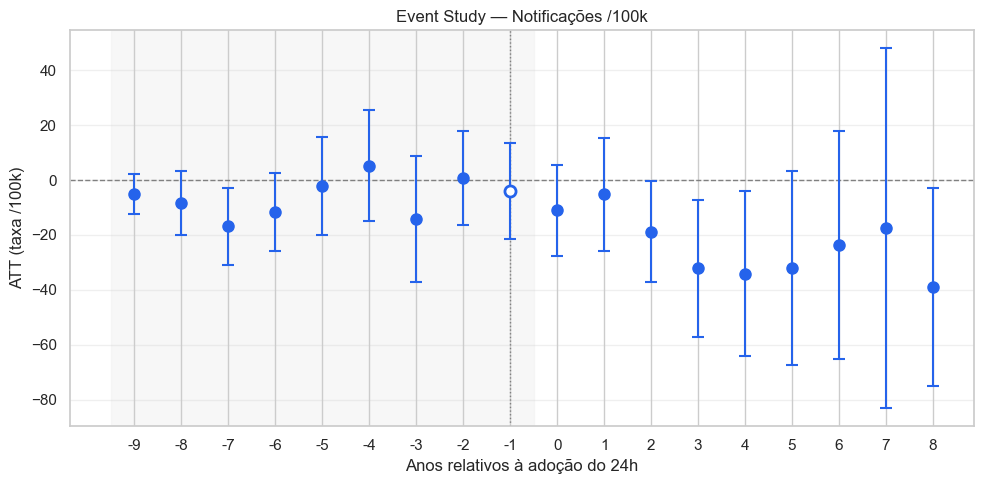

In [6]:
for col, lab in zip(metr_taxa, ["Feminicídios /100k", "Notificações /100k"]):
    r_es = rodar_cs(col, "event_study")
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_event_study(r_es, ax=ax, show=False, title=f"Event Study — {lab}",
                     xlabel="Anos relativos à adoção do 24h", ylabel="ATT (taxa /100k)")
    plt.tight_layout(); plt.show()

## 8. ATT(g,t): heatmap grupo-tempo e efeitos por coorte

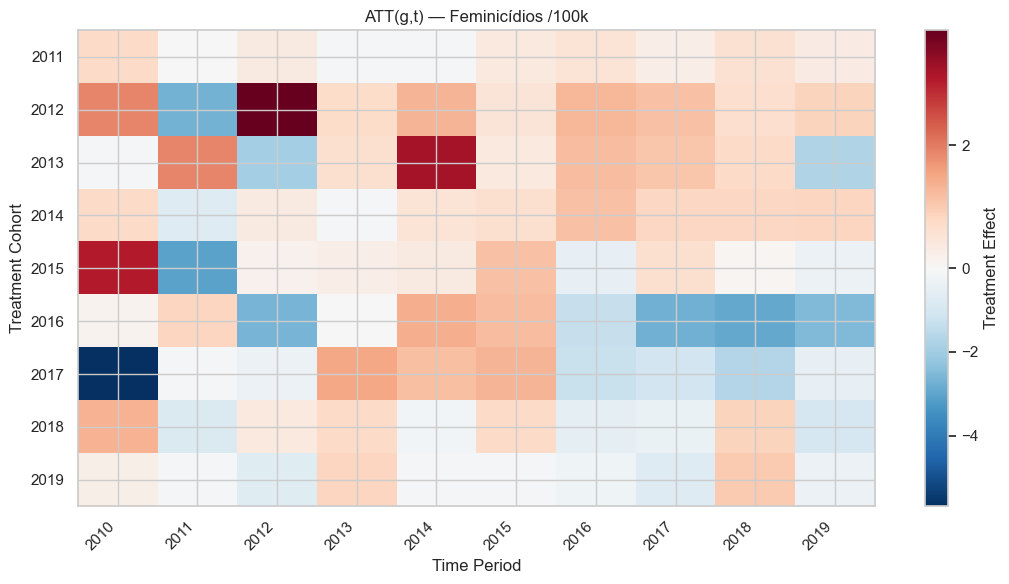

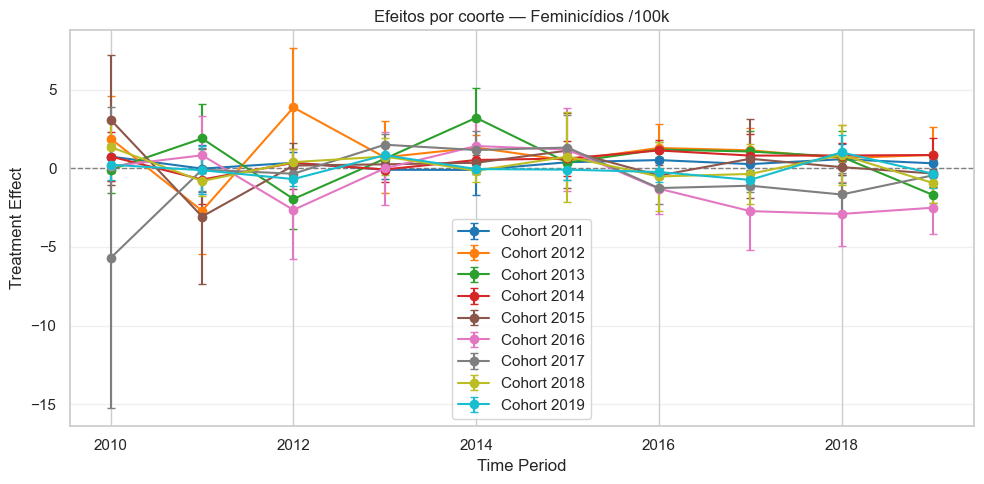

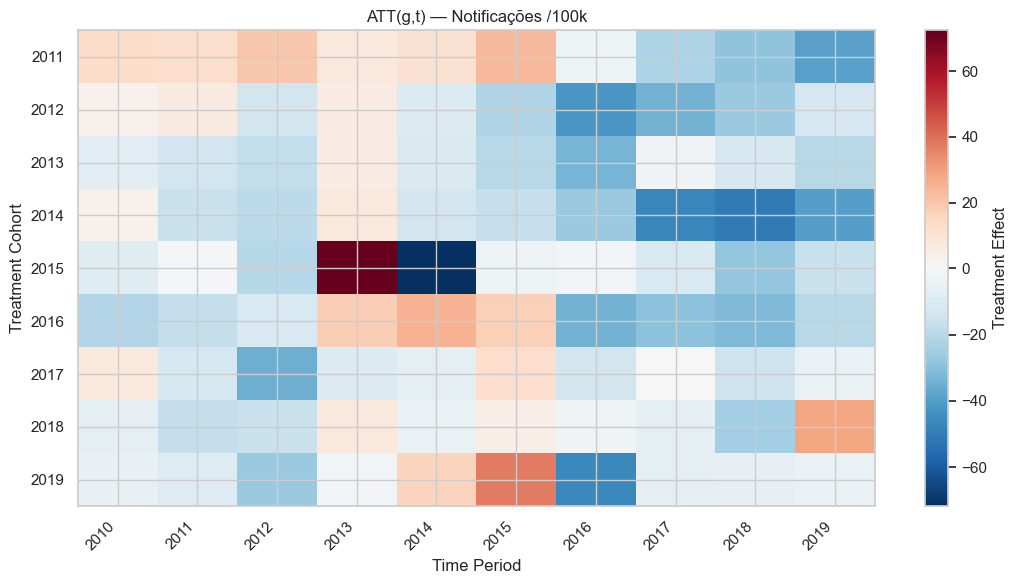

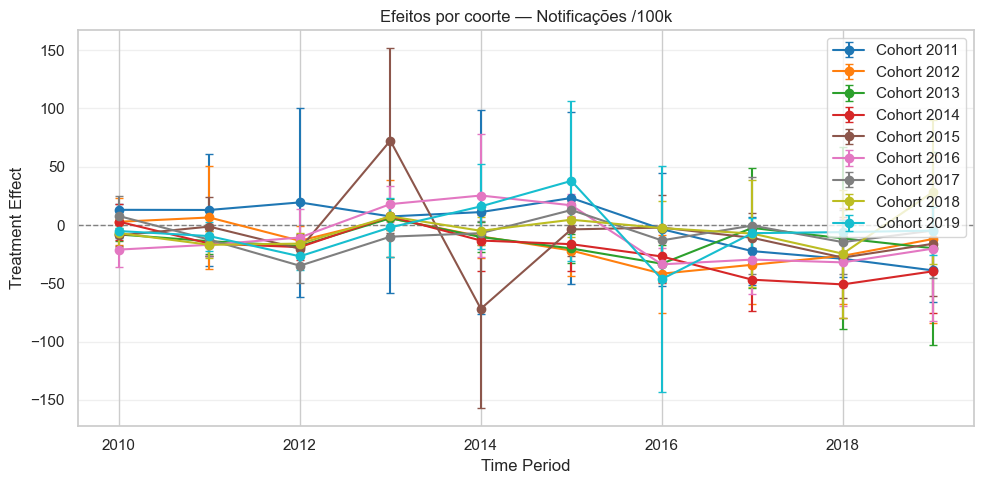

In [7]:
for col, lab in zip(metr_taxa, ["Feminicídios /100k", "Notificações /100k"]):
    r_es = rodar_cs(col, "event_study")
    fig, ax = plt.subplots(figsize=(11, 6))
    plot_group_time_heatmap(r_es, ax=ax, show=False, annotate=False,
                            title=f"ATT(g,t) — {lab}")
    plt.tight_layout(); plt.show()

    r_g = rodar_cs(col, "group")
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_group_effects(r_g, ax=ax, show=False, title=f"Efeitos por coorte — {lab}")
    plt.tight_layout(); plt.show()

## 9. Teste conjunto de pré-tendências

H0: todos os coeficientes pré-tratamento do event study = 0. p < 0,05 sinaliza
**violação** das tendências paralelas (estimativa não confiável sem covariáveis).

In [8]:
from scipy import stats

def teste_pretrends(col):
    r_es = rodar_cs(col, "event_study")
    pre = [(int(t), e) for t, e in r_es.event_study_effects.items() if int(t) < 0
           and isinstance(e, dict) and e.get("se")]
    z2 = [(e["effect"]/e["se"])**2 for _, e in pre]
    wald, k = sum(z2), len(z2)
    pval = 1 - stats.chi2.cdf(wald, df=k)
    n_sig = sum(v > stats.chi2.ppf(0.95, df=1) for v in z2)
    return wald, pval, k, n_sig

print("Desfecho            | Wald   | p-valor | nº pré | indiv. signif.")
for col, lab in zip(metr_taxa, ["Feminicídios /100k", "Notificações /100k"]):
    w, p, k, ns = teste_pretrends(col)
    flag = "  <-- VIOLAÇÃO" if p < 0.05 else "  ok"
    print(f"{lab:20s}| {w:6.2f} | {p:7.4f} | {k:^6d} | {ns}{flag}")

Desfecho            | Wald   | p-valor | nº pré | indiv. signif.


Feminicídios /100k  |  12.95 |  0.1650 |   9    | 1  ok


Notificações /100k  |  24.14 |  0.0041 |   9    | 2  <-- VIOLAÇÃO


## 10. Robustez — estimador alternativo (Borusyak et al., BJS Imputation)

In [9]:
for col, lab in zip(metr_taxa, ["Feminicídios /100k", "Notificações /100k"]):
    try:
        bjs = ImputationDiD().fit(painel, outcome=col, **TREAT)
        att, se = bjs.overall_att, bjs.overall_se
        att = att if np.isfinite(att) else np.nan
        cs_att = resultados[col].overall_att
        print(f"{lab:22s} CS={cs_att:+.3f} | BJS={att:+.3f} (SE {se:.3f})")
    except Exception as e:
        print(f"{lab}: BJS falhou -> {e}")

Feminicídios /100k     CS=+0.438 | BJS=+0.327 (SE 0.135)
Notificações /100k     CS=-20.513 | BJS=-26.306 (SE 8.505)


## 11. Discussão — leitura honesta dos resultados

**Após normalizar por população**, o CS DiD em taxa /100k indica:

| Desfecho | ATT | p-valor | Esperado | Obtido |
|---|---|---|---|---|
| Notificações /100k | ≈ **−20,5** | ≈ 0,001 | ↑ acesso | ↓ **significativo** |
| Feminicídios /100k | ≈ **+0,44** | ≈ 0,082 | ↓ letalidade | ↑ marginal |

Ambos os sinais são **contrários à hipótese**. Mas a interpretação exige cautela:

1. **Pré-tendências (seção 9):** *feminicídios* passa no teste (tendências paralelas
   plausíveis); *notificações* **falha** — parte do "−20,5" é tendência preexistente,
   não efeito causal. Esse número ainda não é confiável sem covariáveis.

2. **Endogeneidade da política:** municípios provavelmente convertem para 24h *em
   resposta* a um problema crescente de violência. Se a adoção segue uma piora, o
   estimador atribui essa piora ao tratamento (viés para cima no feminicídio).

3. **Cifra oculta ao contrário:** queda nas notificações/100k pode significar *menos
   acesso* (ruim) **ou** *menos violência real* (bom) — o sinal sozinho não distingue.

**Próximo passo para identificação válida:** anexar covariáveis socioeconômicas
(IDH, renda, urbanização) e usar `estimation_method='dr'` (doubly-robust), que
condiciona as tendências paralelas e **dispensa um PSM separado** — o CS já estima o
escore de propensão internamente. Testar também `control_group='not_yet_treated'` e
`anticipation=1` para a endogeneidade de adoção.

> Este notebook documenta a estimativa **incondicional** (sem covariáveis). É a base
> metodológica; a identificação causal final depende do ajuste por covariáveis.